# 11 — Frequência, abrangência e gravidade dos desastres

Esta etapa é uma extensão informada pelos resultados anteriores. Consulte `docs/segunda_etapa_protocolo.md`, registrado no GitHub antes dos testes. Precedência preditiva e associações condicionais não identificam causalidade estrutural.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT/'src'))
from segunda_etapa import *
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(12,5),'font.size':11})
pd.set_option('display.max_columns', 20)
def tabela(d):
    display(d.round(5))
def resumo(d):
    tabela(d.groupby(['Família','Período','Categoria resultado']).size().reset_index(name='Modelos'))


## 1. O que as medidas representam
Protocolos medem frequência de registros; municípios distintos medem abrangência. Deslocamento e habitações medem registros de danos, sem indivíduos/imóveis únicos. Não somamos componentes a totais. Campos ausentes propagam ausência no agregado; nenhum protocolo gera zero observado. Zeros preenchidos na fonte não garantem que o dano foi investigado.

In [2]:
a,v=exposure()
tabela(a)
tabela(v)
tabela(read('sobreposicoes'))
tabela(read('monetarios'))

,Campo,Registros,Ausentes,Conversão inválida,Negativos,Zeros informados,Mediana,Q99,Máximo,Participação máximo
0,DH_DESABRIGADOS,40339,0,0,0,35157,0.0,4.178600e+02,2.849000e+04,0.02845
1,DH_DESALOJADOS,40339,0,0,0,31407,0.0,2.500000e+03,1.650000e+05,0.03413
2,DM_Uni Habita Danificadas,40339,0,0,0,33407,0.0,8.206200e+02,4.500000e+04,0.02207
3,DM_Uni Habita Destruidas,40339,0,0,0,37038,0.0,7.000000e+01,3.600000e+04,0.11781
4,PEPR_total_privado,40339,0,0,0,20636,0.0,1.491921e+08,1.041608e+10,0.02595
5,PEPR_Agricultura (R$),40339,0,0,0,22620,0.0,1.112319e+08,1.934640e+09,0.00778
6,PEPR_Pecuária (R$),40339,0,0,0,25706,0.0,3.138246e+07,8.086332e+08,0.01064
7,PEPR_Indústria (R$),40339,0,0,0,38458,0.0,2.572242e+06,5.867680e+08,0.06027
8,PEPR_Comércio (R$),40339,0,0,0,37247,0.0,2.997015e+06,9.838278e+09,0.17019
9,PEPR_Serviços (R$),40339,0,0,0,37384,0.0,2.350972e+06,7.256644e+08,0.07971


,Exposição,Cobertura protocolos,Cobertura células,Meses nacionais completos,Zeros não distinguíveis de omissão,Elegível
0,Clima | Deslocamento,1.0,1.0,144,zeros mantidos como reportados; completude rea...,True
1,Clima | Habitações,1.0,1.0,144,zeros mantidos como reportados; completude rea...,True


,Deslocamento ambos campos positivos,Habitações ambos campos positivos,Nota
0,4106,2017,Não é possível certificar pessoas/imóveis únic...


,Campo,Registros comparáveis,Diferenças acima R$1,Diferença máxima,Inferência
0,PEPR_total_privado,40339,0,0.02,Excluído: mês-base/correção desta versão não c...


## 2. Foco climático e cobertura
O foco usa COBRADE12/13/14, mantendo o grupo e a tipologia originais. Eventos geológicos podem ser desencadeados por chuva, mas isso não está certificado em cada registro; ficam na comparação histórica. Valores monetários não entram na inferência porque o mês-base desta extração não foi confirmado; deflacioná-los novamente poderia produzir erro.

,code,grupo_de_desastre,descricao_tipologia,clima,subito,seca,Protocolos
0,11110,Outros,Outros,False,False,False,87
1,11120,Outros,Outros,False,False,False,1
2,11311,Hidrológico,Movimento de Massa,False,False,False,36
3,11312,Hidrológico,Movimento de Massa,False,False,False,10
4,11313,Hidrológico,Movimento de Massa,False,False,False,18
5,11314,Hidrológico,Movimento de Massa,False,False,False,10
6,11321,Hidrológico,Movimento de Massa,False,False,False,828
7,11331,Hidrológico,Movimento de Massa,False,False,False,118
8,11332,Hidrológico,Movimento de Massa,False,False,False,30
9,11340,Hidrológico,Movimento de Massa,False,False,False,53


,Ano,Campo,Cobertura,Zeros,Soma reportada
0,2013,DH_DESABRIGADOS,1.0,0.86431,1.558120e+05
1,2014,DH_DESABRIGADOS,1.0,0.86707,1.106110e+05
2,2015,DH_DESABRIGADOS,1.0,0.85045,7.933100e+04
3,2016,DH_DESABRIGADOS,1.0,0.91879,1.567600e+04
4,2017,DH_DESABRIGADOS,1.0,0.90903,3.956500e+04
...,...,...,...,...,...
115,2020,PEPR_Serviços (R$),1.0,0.94330,2.105180e+08
116,2021,PEPR_Serviços (R$),1.0,0.95135,3.591931e+08
117,2022,PEPR_Serviços (R$),1.0,0.94384,7.365158e+08
118,2023,PEPR_Serviços (R$),1.0,0.94311,2.412263e+08


,UF,Exposição,Cobertura protocolos,Total registros
0,AC,Clima | Deslocamento,1.0,193
1,AL,Clima | Deslocamento,1.0,681
2,AM,Clima | Deslocamento,1.0,688
3,AP,Clima | Deslocamento,1.0,98
4,BA,Clima | Deslocamento,1.0,3243
5,CE,Clima | Deslocamento,1.0,1449
6,DF,Clima | Deslocamento,1.0,9
7,ES,Clima | Deslocamento,1.0,1078
8,GO,Clima | Deslocamento,1.0,365
9,MA,Clima | Deslocamento,1.0,503


,Indicador,Clima | Protocolos,Clima | Municípios,Clima | Deslocamento,Clima | Habitações
0,Clima | Protocolos,1.00000,0.99083,0.48191,0.32272
1,Clima | Municípios,0.99083,1.00000,0.50345,0.33773
2,Clima | Deslocamento,0.48191,0.50345,1.00000,0.52986
3,Clima | Habitações,0.32272,0.33773,0.52986,1.00000


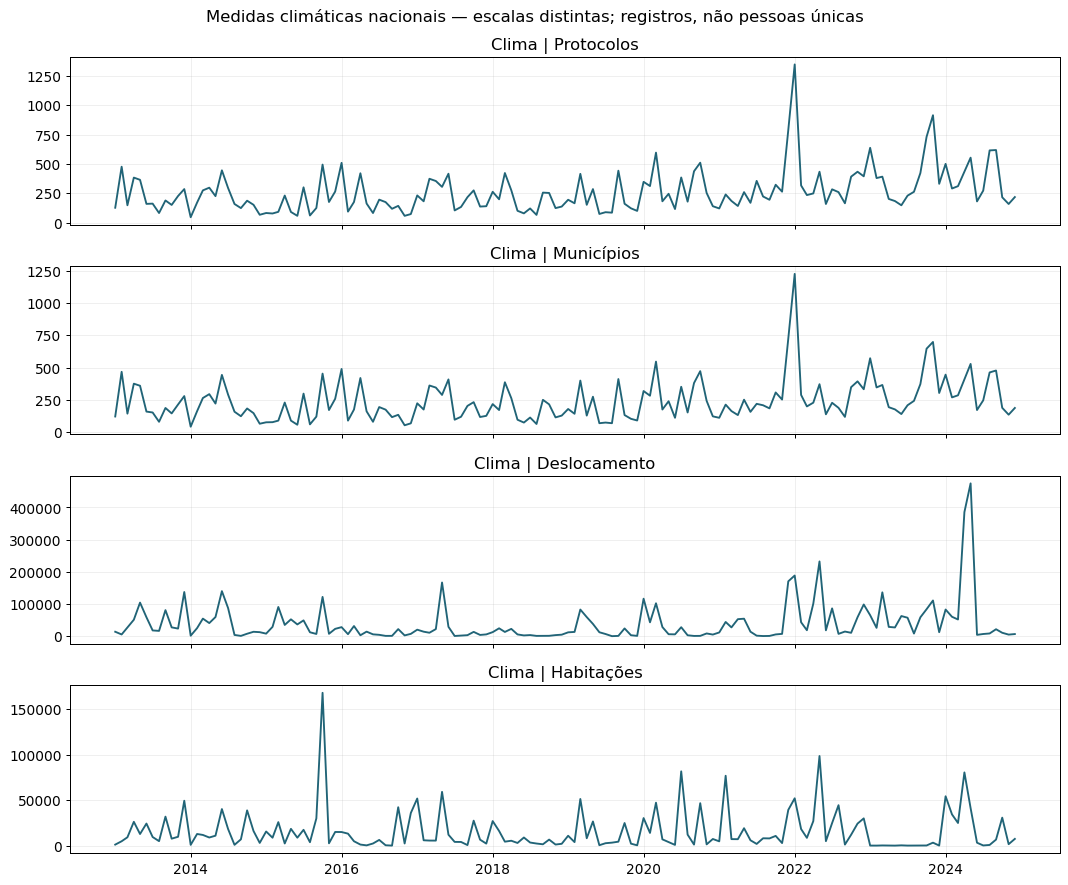

In [3]:
tabela(read('classificacao_climatica'))
tabela(read('cobertura_ano'))
tabela(read('cobertura_uf'))
tabela(read('correlacao_indicadores'))
figura_exposicao()

## 3. Modelos de exposição
Aplicamos a mesma regra registrada na etapa10. A família nacional preserva50 hipóteses, incluindo categorias inelegíveis com p=1 apenas no ajuste. Não recalculamos os modelos históricos, apenas completamos as oito hipóteses de exposição reservadas.

,Família,Período,Categoria resultado,Modelos
0,DETERMINISTICAS,Total (2013–2024),Diagnósticos inadequados ou inconclusivos,25
1,NACIONAL,Pré-pandemia (até jan/2020),Diagnósticos inadequados ou inconclusivos,23
2,NACIONAL,Pré-pandemia (até jan/2020),Excluído / inviável,2
3,NACIONAL,Total (2013–2024),Diagnósticos inadequados ou inconclusivos,25


,Período,Unidade,Exposição,Indicador,Transformação,Família,Modelo,p próprio,q exposição,q0 preferido,...,Estacionária D,Diagnóstico favorável,Motivo,Família n,p BH,p BY,p Holm,p BH clássico,p BH HC3,Categoria resultado
42,Total (2013–2024),Brasil,Clima | Protocolos,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,1.0,1.0,True,...,True,False,NaN,50,0.79946,1.0,1.0,0.91923,0.97701,Diagnósticos inadequados ou inconclusivos
43,Total (2013–2024),Brasil,Clima | Municípios,Municípios,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,1.0,1.0,True,...,True,False,NaN,50,0.80716,1.0,1.0,0.91923,0.97701,Diagnósticos inadequados ou inconclusivos
44,Total (2013–2024),Brasil,Clima | Deslocamento,Deslocamento,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,1.0,1.0,True,...,True,False,NaN,50,0.92316,1.0,1.0,0.95758,0.97701,Diagnósticos inadequados ou inconclusivos
45,Total (2013–2024),Brasil,Clima | Habitações,Habitações,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,1.0,1.0,True,...,True,False,NaN,50,0.77091,1.0,1.0,0.91923,0.97701,Diagnósticos inadequados ou inconclusivos
46,Pré-pandemia (até jan/2020),Brasil,Clima | Protocolos,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,3.0,1.0,True,...,True,False,NaN,50,0.77091,1.0,1.0,0.91923,0.97701,Diagnósticos inadequados ou inconclusivos
47,Pré-pandemia (até jan/2020),Brasil,Clima | Municípios,Municípios,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,3.0,1.0,True,...,True,False,NaN,50,0.77091,1.0,1.0,0.91923,0.97701,Diagnósticos inadequados ou inconclusivos
48,Pré-pandemia (até jan/2020),Brasil,Clima | Deslocamento,Deslocamento,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,3.0,1.0,True,...,True,False,NaN,50,1.00000,1.0,1.0,1.00000,1.00000,Diagnósticos inadequados ou inconclusivos
49,Pré-pandemia (até jan/2020),Brasil,Clima | Habitações,Habitações,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,3.0,1.0,True,...,True,False,NaN,50,0.80716,1.0,1.0,0.91923,0.97701,Diagnósticos inadequados ou inconclusivos
71,Total (2013–2024),Brasil,Clima | Protocolos,Protocolos,ΔI; Δlog(1+exposição),DETERMINISTICAS,ADL BIC + 11 dummies + I12 + janela pandemia,1.0,1.0,True,...,True,False,NaN,25,0.95244,1.0,1.0,0.96084,0.96025,Diagnósticos inadequados ou inconclusivos
72,Total (2013–2024),Brasil,Clima | Municípios,Municípios,ΔI; Δlog(1+exposição),DETERMINISTICAS,ADL BIC + 11 dummies + I12 + janela pandemia,1.0,1.0,True,...,True,False,NaN,25,0.95244,1.0,1.0,0.96084,0.96025,Diagnósticos inadequados ou inconclusivos


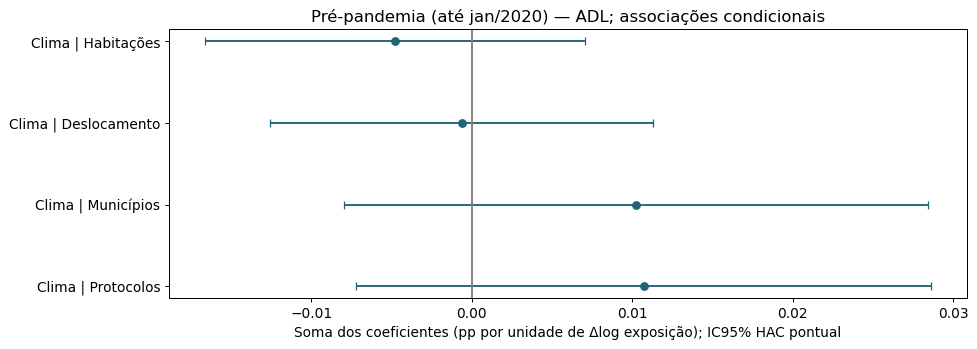

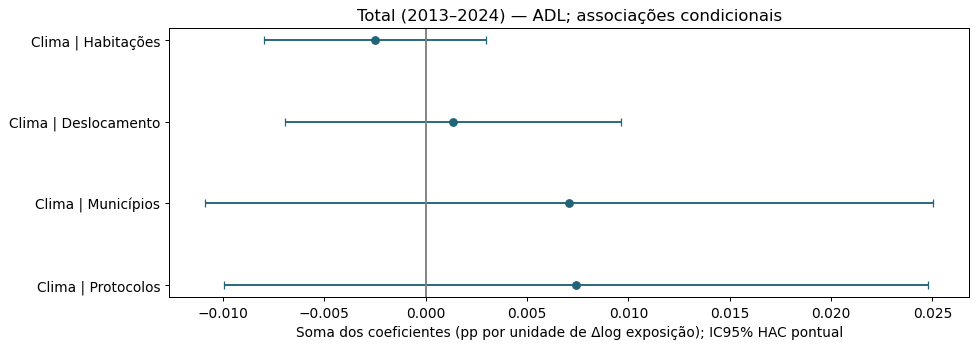

/workspace/scratch/1b453e109626/tcc/src/segunda_etapa.py:100: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r={'BG1 p':acorr_breusch_godfrey(model,nlags=1)[1],'BG12 p':acorr_breusch_godfrey(model,nlags=12)[1],'BP p':het_breuschpagan(model.resid,model.model.exog)[1],'ARCH3 p':het_arch(model.resid,nlags=3)[1],'CUSUM p':breaks_cusumolsresid(model.resid,ddof=len(model.params))[1],'RESET p':linear_reset(model,power=2,test_type='fitted',use_f=True,cov_type='HC3').pvalue,'ACF12':acf(model.resid,nlags=12,fft=False)[12],'Raiz própria':roots(model)}
/root/.local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tup

In [4]:
r=national(EXPOS,extra=True)
resumo(r)
tabela(r[r.Exposição.isin(EXPOS)])
figura_nacional(r[r.Exposição.isin(EXPOS)])

## 4. Disponibilidade temporal
Data_Registro permite descrever atrasos, mas não reconstrói vintages de publicação e revisões. O exercício posterior de previsão é pseudo-OOS com dados revisados; não certifica uso operacional em tempo real.

In [5]:
tabela(read('disponibilidade_atlas'))
tabela(ty(['Clima | Protocolos'],extra=True))
tabela(decisions())
checkpoint('11')

,n,Data registro ausente/inválida,Registro anterior ao evento,Mediana dias,Q90 dias,Q99 dias,Proporção registrado depois mês evento,Limitação
0,40339,0,11,1.0,12.0,77.0,0.1182,Data registro não é vintage de publicação/revi...


,Período,Exposição,Família,d_max,p,Diagnóstico favorável,k,Lags totais,Restrições,Wald chi2,n efetivo,Portmanteau p,Motivo,Família n,p BH,p BY,p Holm,Categoria resultado
0,Total (2013–2024),Total nacional,TY,1,0.42894,True,2.0,3.0,"D1..Dk, sem restringir lag adicional",1.69285,141.0,0.12949,Robustez em níveis: integração limite I(1); ra...,4,0.86115,1.0,1.0,Não significativo
1,Pré-pandemia (até jan/2020),Total nacional,TY,1,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,Gate: integração/dinâmica ADL inadequada ou in...,4,1.00000,1.0,1.0,Excluído / inviável
2,Total (2013–2024),Clima | Protocolos,TY,1,0.43058,True,2.0,3.0,"D1..Dk, sem restringir lag adicional",1.68526,141.0,0.14058,Robustez em níveis: integração limite I(1); ra...,4,0.86115,1.0,1.0,Não significativo
3,Pré-pandemia (até jan/2020),Clima | Protocolos,TY,1,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,Gate: integração/dinâmica ADL inadequada ou in...,4,1.00000,1.0,1.0,Excluído / inviável


,Procedimento,Decisão,Justificativa
0,Bootstrap temporal H0,Não aplicado,Teste condicional à seleção; bootstrap defensá...
1,Simulação de poder,Não aplicada,Não atribuir tamanho/poder confiável a um DGP ...
2,Controles econômicos adicionais,Não incluídos,Não disponíveis na entrada com cobertura ofici...
3,GMM,Não aplicado,"N=27,T longo; evitar proliferação de instrumen..."


/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self.